# This is after doing the feature eng first step, I am now processing the text based cols

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('housing_data_after_feature_eng.csv').drop(columns={'Unnamed: 0'})
pd.set_option('display.max_columns', None)

In [8]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score,parking_spaces,parking_quality_score,has_garage,parking_adequacy,county,zip_price_tier
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225.0,single family,706.0,1880.0,Arlington,fireplace; stainless steel; marble,living room; office; dining room,range; dryer; washer,circuit breakers,public sewer,public,"for gas range, for gas dryer, washer hookup",4.0,off street,81.0,61.0,Nearby,NaN,Ottoson,0.4,Arlington,1.4,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5.0,2474,145.0,73.0,0.900,2.85,4.0,0.0,0,Adequate,Middlesex,Mid-tier
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978.0,single family,751.0,1880.0,Arlington,granite countertops; stainless steel; fireplace,bonus room; living room; dining room,range; oven,"circuit breakers, 100 amp service",public sewer,public,"for gas range, for electric oven",3.0,"paved drive, tandem, paved",69.0,59.0,Bishop,0.1,Ottoson,0.1,Arlington,0.7,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1.0,NaN,799000,Ultra Compact,4.0,2474,145.0,65.0,0.300,2.85,3.0,1.0,0,Adequate,Middlesex,Mid-tier
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603.0,single family,552.0,1952.0,Arlington,fireplace; laminate,living room; family room; dining room,range; oven; washer,circuit breakers,public sewer,public,"for gas range, for gas oven, for gas dryer, wa...",5.0,off street,32.0,35.0,Nearby,5.0,Ottoson,0.2,Additional,5.0,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7.0,2474,73.0,33.2,3.400,2.85,5.0,0.0,0,Abundant,Middlesex,Mid-tier
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219.0,single family,547.0,1926.0,Arlington,fireplace; hardwood floors,living room; office; dining room,range,NaN,public sewer,public,NaN,2.0,off street,84.0,54.0,Brackett,0.7,Ottoson,0.7,Arlington,0.7,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6.0,2476,99.0,72.0,0.700,2.95,2.0,0.0,0,Basic,Middlesex,Mid-tier
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339.0,condo,547.0,1908.0,Arlington,fireplace; hardwood floor,living room; family room; dining room,range,circuit breakers,public sewer,public,NaN,1.0,"off street, tandem, paved",77.0,96.0,Thompson,0.1,Ottoson,0.1,Major,5.0,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1.0,NaN,668000,Unknown,NaN,2474,117.0,84.6,1.733,2.95,1.0,1.0,0,Limited,Middlesex,Mid-tier


# Columns to process:

`interior_features, other_rooms, appliances, utilities_Electric, utilities_Sewer, utilities_Water, utilities_Utilities, parking_parking_features, property_history`

In [13]:
for i in df['interior_features'].unique():
  print(i)

fireplace; stainless steel; marble
granite countertops; stainless steel; fireplace
fireplace; laminate
fireplace; hardwood floors
fireplace; hardwood floor
granite countertops; stainless steel; hardwood floors; fireplace
fireplace
fireplace; stainless steel; walk-in closet; laminate
laminate; granite countertops; hardwood floors; fireplace; stainless steel
laminate; crown molding; bay window; fireplace; carpet
granite countertops; fireplace; carpet; stainless steel; walk-in closet
fireplace; stainless steel; skylight
fireplace; walk-in closet
fireplace; stainless steel
fireplace; carpet
fireplace; skylight
fireplace; stainless steel; crown molding; marble
hardwood floor; marble; hardwood floors; fireplace; walk-in closet
fireplace; stainless steel; hardwood floors
laminate; crown molding; fireplace; stainless steel; walk-in closet
stainless steel; fireplace
walk-in closet; carpet; fireplace
vaulted ceiling; fireplace; skylight; granite countertops; hardwood floors
fireplace; hardwood f

In [20]:
import pandas as pd
import numpy as np

def process_amenities(df):
    """Extract amenity features from interior_features column"""

    df = df.copy()

    # Define keywords
    keywords = {
        'flooring': ['hardwood floors', 'hardwood floor', 'marble', 'tile floors', 'tile floor', 'carpet', 'laminate'],
        'kitchen': ['granite countertops', 'granite countertop', 'stainless steel'],
        'luxury': ['fireplace', 'marble'],
        'storage': ['walk-in closet'],
        'architectural': ['vaulted ceiling', 'crown molding', 'bay window', 'skylight']
    }

    weights = {'flooring': 1, 'kitchen': 2, 'luxury': 3, 'storage': 1, 'architectural': 2}

    def extract_features(text):
        if pd.isna(text):
            amenities = []
        else:
            amenities = [x.strip().lower() for x in str(text).split(';')]
            # Normalize variations
            amenities = ['hardwood floors' if x == 'hardwood floor' else x for x in amenities]
            amenities = ['tile floors' if x == 'tile floor' else x for x in amenities]
            amenities = ['granite countertops' if x in ['granite countertop', 'granite  countertops'] else x for x in amenities]

        result = {'total_amenities': len(amenities), 'premium_score': 0}

        # Check categories
        for category, kw_list in keywords.items():
            has_cat = any(kw in amenities for kw in kw_list)
            count = sum(1 for kw in kw_list if kw in amenities)

            result[f'has_{category}'] = has_cat
            result[f'{category}_count'] = count
            result['premium_score'] += count * weights[category]

        return pd.Series(result)

    # Apply processing
    features = df['interior_features'].apply(extract_features)

    # Add to dataframe
    for col in features.columns:
        df[f'amenity_{col}'] = features[col]

    return df

def summary_stats(df):
    """Print summary statistics"""
    total = len(df)
    print(f"Total properties: {total}")

    categories = ['flooring', 'kitchen', 'luxury', 'storage', 'architectural']
    for cat in categories:
        col = f'amenity_has_{cat}'
        if col in df.columns:
            count = df[col].sum()
            pct = count/total*100 if total > 0 else 0
            print(f"{cat}: {count} ({pct:.1f}%)")

    if 'amenity_premium_score' in df.columns:
        print(f"Avg premium score: {df['amenity_premium_score'].mean():.2f}")

# Usage:
# df_processed = process_amenities(df)  # Process all data
# summary_stats(df_processed)  # Get summary

In [21]:
# Process all data
df_processed = process_amenities(df)

# Get summary
summary_stats(df_processed)

Total properties: 7941
flooring: 5652 (71.2%)
kitchen: 2797 (35.2%)
luxury: 7738 (97.4%)
storage: 2465 (31.0%)
architectural: 1897 (23.9%)
Avg premium score: 6.09


In [22]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score,parking_spaces,parking_quality_score,has_garage,parking_adequacy,county,zip_price_tier,amenity_total_amenities,amenity_premium_score,amenity_has_flooring,amenity_flooring_count,amenity_has_kitchen,amenity_kitchen_count,amenity_has_luxury,amenity_luxury_count,amenity_has_storage,amenity_storage_count,amenity_has_architectural,amenity_architectural_count
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225.0,single family,706.0,1880.0,Arlington,fireplace; stainless steel; marble,living room; office; dining room,range; dryer; washer,circuit breakers,public sewer,public,"for gas range, for gas dryer, washer hookup",4.0,off street,81.0,61.0,Nearby,NaN,Ottoson,0.4,Arlington,1.4,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5.0,2474,145.0,73.0,0.900,2.85,4.0,0.0,0,Adequate,Middlesex,Mid-tier,3,9,True,1,True,1,True,2,False,0,False,0
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978.0,single family,751.0,1880.0,Arlington,granite countertops; stainless steel; fireplace,bonus room; living room; dining room,range; oven,"circuit breakers, 100 amp service",public sewer,public,"for gas range, for electric oven",3.0,"paved drive, tandem, paved",69.0,59.0,Bishop,0.1,Ottoson,0.1,Arlington,0.7,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1.0,NaN,799000,Ultra Compact,4.0,2474,145.0,65.0,0.300,2.85,3.0,1.0,0,Adequate,Middlesex,Mid-tier,3,7,False,0,True,2,True,1,False,0,False,0
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603.0,single family,552.0,1952.0,Arlington,fireplace; laminate,living room; family room; dining room,range; oven; washer,circuit breakers,public sewer,public,"for gas range, for gas oven, for gas dryer, wa...",5.0,off street,32.0,35.0,Nearby,5.0,Ottoson,0.2,Additional,5.0,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7.0,2474,73.0,33.2,3.400,2.85,5.0,0.0,0,Abundant,Middlesex,Mid-tier,2,4,True,1,False,0,True,1,False,0,False,0
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219.0,single family,547.0,1926.0,Arlington,fireplace; hardwood floors,living room; office; dining room,range,NaN,public sewer,public,NaN,2.0,off street,84.0,54.0,Brackett,0.7,Ottoson,0.7,Arlington,0.7,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6.0,2476,99.0,72.0,0.700,2.95,2.0,0.0,0,Basic,Middlesex,Mid-tier,2,4,True,1,False,0,True,1,False,0,False,0
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339.0,condo,547.0,

In [29]:
target = 'price'

numerical_cols = ['beds', 'baths', 'sqft','mobility_score','avg_school_distance_miles','weighted_risk_score','price_per_sqft', 'estimated_monthly_payment','amenity_total_amenities','amenity_premium_score','amenity_flooring_count','amenity_kitchen_count']

categorical_cols = ['property_type', 'region', 'zip_code', 'sqft_lot_caterogy','county','zip_price_tier']

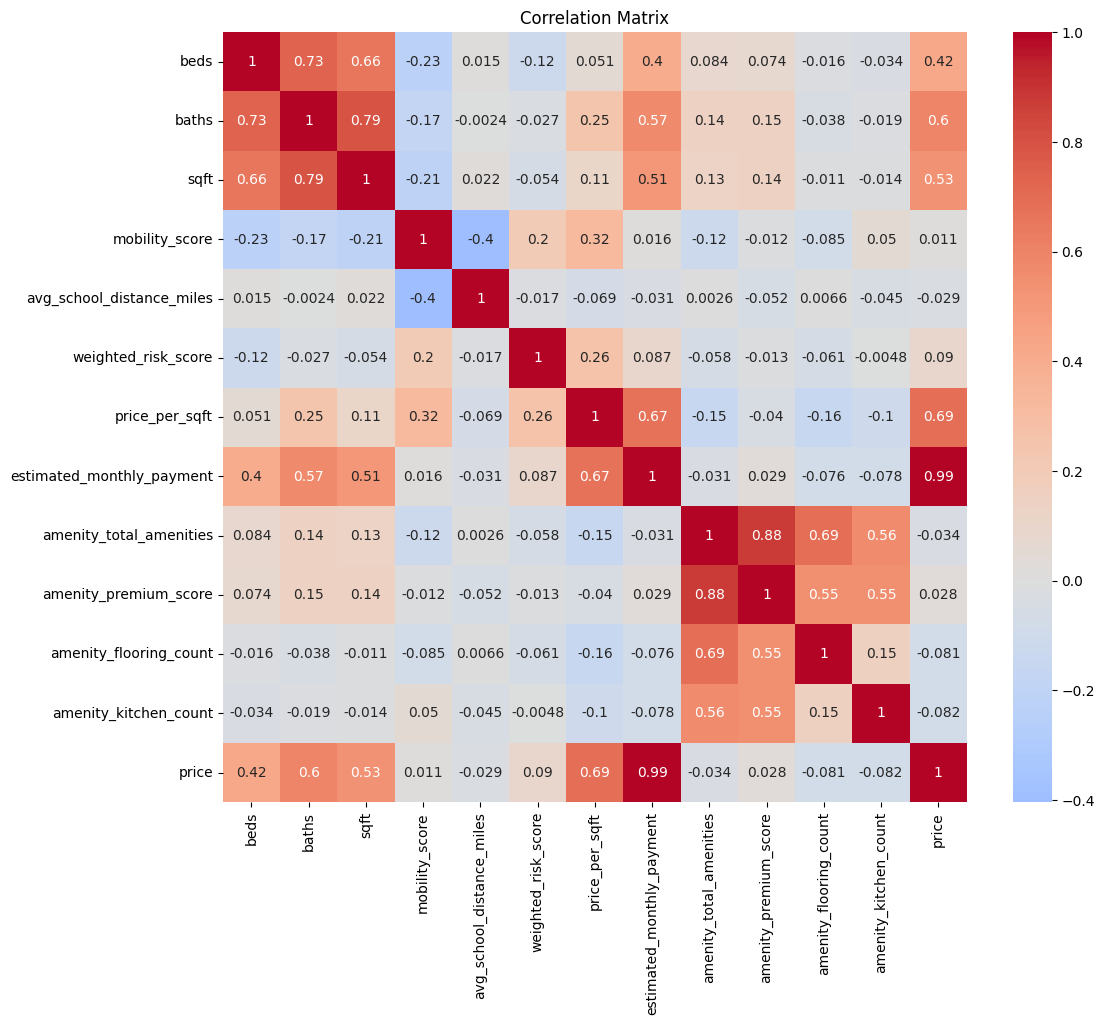

In [32]:
corr_matrix = df[numerical_cols + [target]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


In [34]:
# Test correlations for all text columns
text_cols = ['interior_features', 'other_rooms', 'appliances',
             'utilities_Electric', 'utilities_Sewer', 'utilities_Water',
             'utilities_Utilities', 'parking_parking_features', 'property_history']

for col in text_cols:
    if col in df.columns:
        # Simple word count or length as proxy
        df[f'{col}_length'] = df[col].astype(str).str.len()
        corr = df[f'{col}_length'].corr(df['price'])
        print(f"{col}: {corr:.3f}")

interior_features: -0.042
other_rooms: 0.033
appliances: -0.004
utilities_Electric: -0.063
utilities_Sewer: -0.043
utilities_Water: 0.005
utilities_Utilities: -0.031
parking_parking_features: 0.048
property_history: 0.021


No good results. Deciding to drop all the amenities etc cols

In [73]:
df = pd.read_csv('housing_data_after_feature_eng.csv').drop(columns={'Unnamed: 0'})

In [74]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,interior_features,other_rooms,appliances,utilities_Electric,utilities_Sewer,utilities_Water,utilities_Utilities,parking_total_spaces,parking_parking_features,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score,parking_spaces,parking_quality_score,has_garage,parking_adequacy,county,zip_price_tier
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225.0,single family,706.0,1880.0,Arlington,fireplace; stainless steel; marble,living room; office; dining room,range; dryer; washer,circuit breakers,public sewer,public,"for gas range, for gas dryer, washer hookup",4.0,off street,81.0,61.0,Nearby,NaN,Ottoson,0.4,Arlington,1.4,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5.0,2474,145.0,73.0,0.900,2.85,4.0,0.0,0,Adequate,Middlesex,Mid-tier
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978.0,single family,751.0,1880.0,Arlington,granite countertops; stainless steel; fireplace,bonus room; living room; dining room,range; oven,"circuit breakers, 100 amp service",public sewer,public,"for gas range, for electric oven",3.0,"paved drive, tandem, paved",69.0,59.0,Bishop,0.1,Ottoson,0.1,Arlington,0.7,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1.0,NaN,799000,Ultra Compact,4.0,2474,145.0,65.0,0.300,2.85,3.0,1.0,0,Adequate,Middlesex,Mid-tier
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603.0,single family,552.0,1952.0,Arlington,fireplace; laminate,living room; family room; dining room,range; oven; washer,circuit breakers,public sewer,public,"for gas range, for gas oven, for gas dryer, wa...",5.0,off street,32.0,35.0,Nearby,5.0,Ottoson,0.2,Additional,5.0,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7.0,2474,73.0,33.2,3.400,2.85,5.0,0.0,0,Abundant,Middlesex,Mid-tier
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219.0,single family,547.0,1926.0,Arlington,fireplace; hardwood floors,living room; office; dining room,range,NaN,public sewer,public,NaN,2.0,off street,84.0,54.0,Brackett,0.7,Ottoson,0.7,Arlington,0.7,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6.0,2476,99.0,72.0,0.700,2.95,2.0,0.0,0,Basic,Middlesex,Mid-tier
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339.0,condo,547.0,1908.0,Arlington,fireplace; hardwood floor,living room; family room; dining room,range,circuit breakers,public sewer,public,NaN,1.0,"off street, tandem, paved",77.0,96.0,Thompson,0.1,Ottoson,0.1,Major,5.0,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1.0,NaN,668000,Unknown,NaN,2474,117.0,84.6,1.733,2.95,1.0,1.0,0,Limited,Middlesex,Mid-tier


In [75]:
df.columns

Index(['url', 'image_url', 'beds', 'baths', 'sqft', 'sqft_lot', 'address',
       'estimated_monthly_payment', 'property_type', 'price_per_sqft',
       'year_built', 'region', 'interior_features', 'other_rooms',
       'appliances', 'utilities_Electric', 'utilities_Sewer',
       'utilities_Water', 'utilities_Utilities', 'parking_total_spaces',
       'parking_parking_features', 'walk_score', 'bike_score',
       'elementary_school_name', 'elementary_school_distance',
       'middle_school_name', 'middle_school_distance', 'high_school_name',
       'high_school_distance', 'flood_risk', 'fire_risk', 'wind_risk',
       'air_risk', 'heat_risk', 'nearby_cities', 'property_history',
       'parking_uncovered_spaces', 'parking_garage_spaces', 'price',
       'sqft_lot_caterogy', 'sqft_lot_cleaned', 'zip_code', 'property_age',
       'mobility_score', 'avg_school_distance_miles', 'weighted_risk_score',
       'parking_spaces', 'parking_quality_score', 'has_garage',
       'parking_adequacy'

In [76]:
df.drop(columns={'interior_features','appliances','utilities_Electric','utilities_Sewer','utilities_Water','utilities_Utilities','parking_parking_features','other_rooms'}, inplace=True)

In [77]:
df.columns

Index(['url', 'image_url', 'beds', 'baths', 'sqft', 'sqft_lot', 'address',
       'estimated_monthly_payment', 'property_type', 'price_per_sqft',
       'year_built', 'region', 'parking_total_spaces', 'walk_score',
       'bike_score', 'elementary_school_name', 'elementary_school_distance',
       'middle_school_name', 'middle_school_distance', 'high_school_name',
       'high_school_distance', 'flood_risk', 'fire_risk', 'wind_risk',
       'air_risk', 'heat_risk', 'nearby_cities', 'property_history',
       'parking_uncovered_spaces', 'parking_garage_spaces', 'price',
       'sqft_lot_caterogy', 'sqft_lot_cleaned', 'zip_code', 'property_age',
       'mobility_score', 'avg_school_distance_miles', 'weighted_risk_score',
       'parking_spaces', 'parking_quality_score', 'has_garage',
       'parking_adequacy', 'county', 'zip_price_tier'],
      dtype='object')

In [78]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,parking_total_spaces,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score,parking_spaces,parking_quality_score,has_garage,parking_adequacy,county,zip_price_tier
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225.0,single family,706.0,1880.0,Arlington,4.0,81.0,61.0,Nearby,NaN,Ottoson,0.4,Arlington,1.4,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5.0,2474,145.0,73.0,0.900,2.85,4.0,0.0,0,Adequate,Middlesex,Mid-tier
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978.0,single family,751.0,1880.0,Arlington,3.0,69.0,59.0,Bishop,0.1,Ottoson,0.1,Arlington,0.7,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1.0,NaN,799000,Ultra Compact,4.0,2474,145.0,65.0,0.300,2.85,3.0,1.0,0,Adequate,Middlesex,Mid-tier
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603.0,single family,552.0,1952.0,Arlington,5.0,32.0,35.0,Nearby,5.0,Ottoson,0.2,Additional,5.0,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7.0,2474,73.0,33.2,3.400,2.85,5.0,0.0,0,Abundant,Middlesex,Mid-tier
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219.0,single family,547.0,1926.0,Arlington,2.0,84.0,54.0,Brackett,0.7,Ottoson,0.7,Arlington,0.7,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6.0,2476,99.0,72.0,0.700,2.95,2.0,0.0,0,Basic,Middlesex,Mid-tier
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339.0,condo,547.0,1908.0,Arlington,1.0,77.0,96.0,Thompson,0.1,Ottoson,0.1,Major,5.0,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1.0,NaN,668000,Unknown,NaN,2474,117.0,84.6,1.733,2.95,1.0,1.0,0,Limited,Middlesex,Mid-tier


In [79]:
print(df['property_history'].head())

0    {'date': '7/15/2025', 'event': 'Listed for sal...
1    {'date': '6/25/2025', 'event': 'Listed for sal...
2    {'date': '7/22/2025', 'event': 'Listed for sal...
3    {'date': '7/22/2025', 'event': 'Listed for sal...
4    {'date': '6/21/2025', 'event': 'Price change',...
Name: property_history, dtype: object


In [80]:
df['property_history'][324]

"{'date': '7/18/2025', 'event': 'Price change', 'price': '$364,000'}; {'date': '6/18/2025', 'event': 'Price change', 'price': '$379,000'}; {'date': '6/4/2025', 'event': 'Price change', 'price': '$389,000'}; {'date': '5/14/2025', 'event': 'Listed for sale', 'price': '$399,000'}; {'date': '4/3/2023', 'event': 'Sold', 'price': '$401,000'}"

In [81]:
df['property_history'][3224]

"{'date': '6/17/2025', 'event': 'Price change', 'price': '$799,000'}; {'date': '4/10/2025', 'event': 'Listed for sale', 'price': '$849,000'}; {'date': '9/14/2023', 'event': 'Sold', 'price': '$775,000'}; {'date': '7/28/2023', 'event': 'Pending sale', 'price': '$740,000'}; {'date': '7/26/2023', 'event': 'Listed for sale', 'price': '$740,000'}"

In [82]:
df['property_history'][2374]

"{'date': '6/26/2025', 'event': 'Price change', 'price': '$3,595,000'}; {'date': '3/31/2025', 'event': 'Price change', 'price': '$3,795,000'}; {'date': '1/24/2025', 'event': 'Price change', 'price': '$3,970,000'}; {'date': '11/27/2024', 'event': 'Listed for sale', 'price': '$3,995,000'}; {'date': '3/7/2022', 'event': 'Listing removed', 'price': '$4,695,000'}"

In [89]:
import pandas as pd
import numpy as np
import re

def extract_property_features(df):
    """Extract key features from property_history column - modifies df in place"""

    def parse_history(history_text):
        if pd.isna(history_text):
            return []

        entries = []
        parts = str(history_text).split('};')

        for part in parts:
            try:
                price_match = re.search(r"'price':\s*'\$([0-9,]+)'", part)
                event_match = re.search(r"'event':\s*'([^']+)'", part)

                if price_match and event_match:
                    price = float(price_match.group(1).replace(',', ''))
                    event = event_match.group(1)
                    entries.append({'price': price, 'event': event})
            except:
                continue

        return entries

    # Extract meaningful features
    price_volatility = []
    price_reduction_total = []
    num_removals = []
    original_list_price = []

    for _, row in df.iterrows():
        history = parse_history(row['property_history'])

        if not history:
            price_volatility.append(0)
            price_reduction_total.append(0)
            num_removals.append(0)
            original_list_price.append(0)
            continue

        prices = [h['price'] for h in history]
        events = [h['event'] for h in history]

        # Price volatility (market uncertainty)
        volatility = np.std(prices) if len(prices) > 1 else 0
        price_volatility.append(volatility)

        # Total price reduction (negative means price increased)
        reduction = prices[0] - prices[-1] if prices else 0
        price_reduction_total.append(reduction)

        # Number of listing removals (market difficulty)
        removals = events.count('Listing removed')
        num_removals.append(removals)

        # Original listing price
        original_price = prices[0] if prices else 0
        original_list_price.append(original_price)

    # Add features to original dataframe
    df['price_volatility'] = price_volatility
    df['price_reduction_total'] = price_reduction_total
    df['num_removals'] = num_removals
    df['original_list_price'] = original_list_price

# Usage:
# extract_property_features(df)  # Modifies df directly
# print("New columns added:", ['price_volatility', 'price_reduction_total', 'num_removals', 'original_list_price'])

In [90]:
extract_property_features(df)  # Adds columns to df
print(df[['price_volatility', 'price_reduction_total', 'num_removals', 'original_list_price']].head())

   price_volatility  price_reduction_total  num_removals  original_list_price
0     190775.778337               481500.0             0             999000.0
1      75258.487893               189000.0             0             799000.0
2     379500.000000               759000.0             0             899000.0
3     358034.448994               815000.0             0             998000.0
4      16004.999219               -47000.0             0             668000.0


In [91]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,estimated_monthly_payment,property_type,price_per_sqft,year_built,region,parking_total_spaces,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,property_history,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score,parking_spaces,parking_quality_score,has_garage,parking_adequacy,county,zip_price_tier,price_volatility,price_reduction_total,num_removals,original_list_price
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474",6225.0,single family,706.0,1880.0,Arlington,4.0,81.0,61.0,Nearby,NaN,Ottoson,0.4,Arlington,1.4,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/15/2025', 'event': 'Listed for sal...",NaN,NaN,999000,Ultra Compact,5.0,2474,145.0,73.0,0.900,2.85,4.0,0.0,0,Adequate,Middlesex,Mid-tier,190775.778337,481500.0,0,999000.0
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474",4978.0,single family,751.0,1880.0,Arlington,3.0,69.0,59.0,Bishop,0.1,Ottoson,0.1,Arlington,0.7,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/25/2025', 'event': 'Listed for sal...",1.0,NaN,799000,Ultra Compact,4.0,2474,145.0,65.0,0.300,2.85,3.0,1.0,0,Adequate,Middlesex,Mid-tier,75258.487893,189000.0,0,799000.0
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",5603.0,single family,552.0,1952.0,Arlington,5.0,32.0,35.0,Nearby,5.0,Ottoson,0.2,Additional,5.0,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,899000,Ultra Compact,7.0,2474,73.0,33.2,3.400,2.85,5.0,0.0,0,Abundant,Middlesex,Mid-tier,379500.000000,759000.0,0,899000.0
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",6219.0,single family,547.0,1926.0,Arlington,2.0,84.0,54.0,Brackett,0.7,Ottoson,0.7,Arlington,0.7,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '7/22/2025', 'event': 'Listed for sal...",NaN,NaN,998000,Ultra Compact,6.0,2476,99.0,72.0,0.700,2.95,2.0,0.0,0,Basic,Middlesex,Mid-tier,358034.448994,815000.0,0,998000.0
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",4339.0,condo,547.0,1908.0,Arlington,1.0,77.0,96.0,Thompson,0.1,Ottoson,0.1,Major,5.0,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,"{'date': '6/21/2025', 'event': 'Price change',...",1.0,NaN,668000,Unknown,NaN,2474,117.0,84.6,1.733,2.95,1.0,1.0,0,Limited,Middlesex,Mid-tier,16004.999219,-47000.0,0,668000.0


In [92]:
target = 'price'

numerical_cols = ['beds', 'baths', 'sqft','mobility_score','avg_school_distance_miles','weighted_risk_score','price_per_sqft', 'estimated_monthly_payment','price_volatility','price_reduction_total','num_removals','original_list_price']


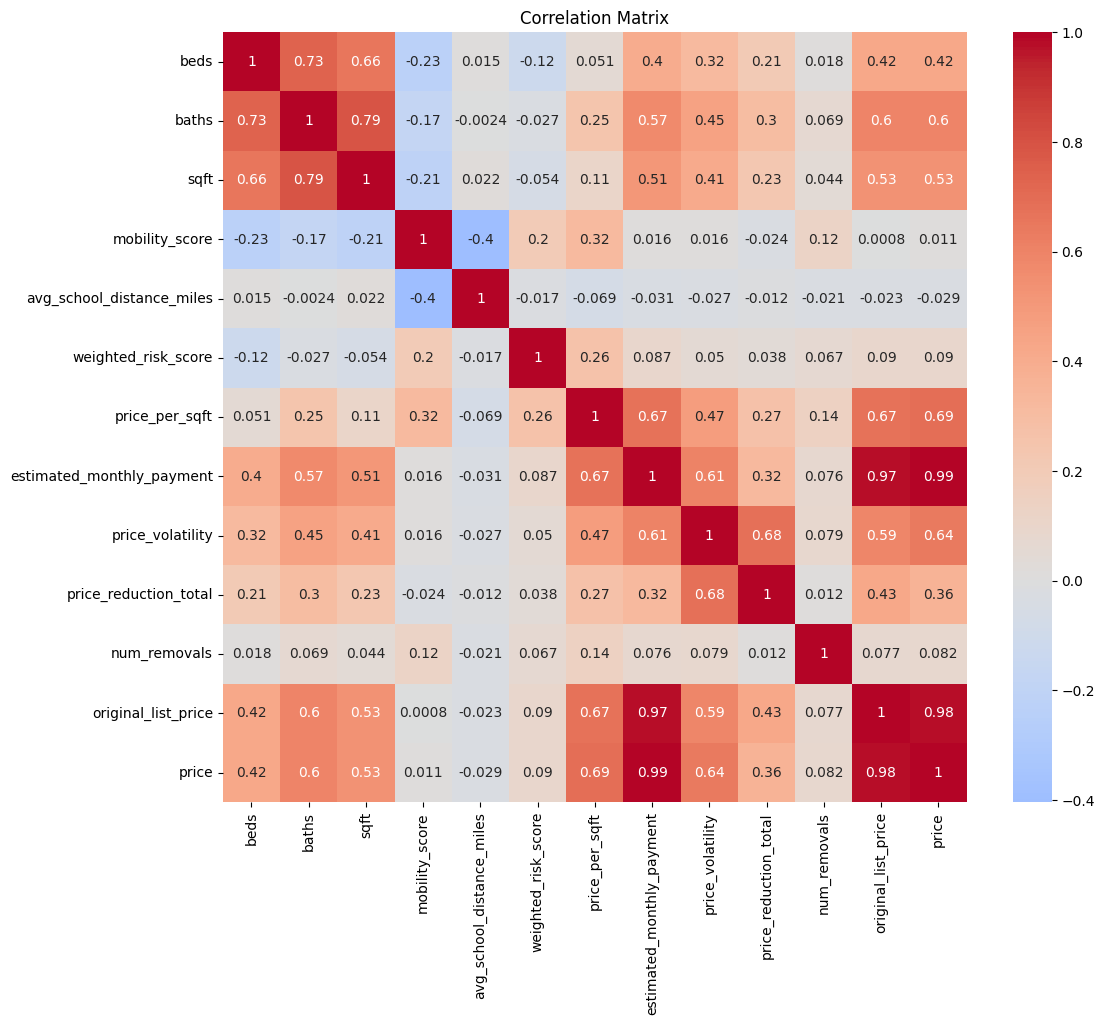

In [93]:
corr_matrix = df[numerical_cols + [target]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Due to major data leakage, i am dropping the high correlated cols

1. monthly payment: i didn't know that the rent is generally calculated from a long fomula.
2. ofc i cant use the original price one
3. the price per sqft will be removed because it's formula is price / sqft which is a data leakage.

In [95]:
columns_to_drop = ['original_list_price', 'estimated_monthly_payment', 'price_per_sqft']
df.drop(columns=columns_to_drop, inplace=True)

In [97]:
df.drop(columns={'property_history', 'num_removals'}, inplace=True)

In [98]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,property_type,year_built,region,parking_total_spaces,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score,parking_spaces,parking_quality_score,has_garage,parking_adequacy,county,zip_price_tier,price_volatility,price_reduction_total
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474",single family,1880.0,Arlington,4.0,81.0,61.0,Nearby,NaN,Ottoson,0.4,Arlington,1.4,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,NaN,NaN,999000,Ultra Compact,5.0,2474,145.0,73.0,0.900,2.85,4.0,0.0,0,Adequate,Middlesex,Mid-tier,190775.778337,481500.0
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474",single family,1880.0,Arlington,3.0,69.0,59.0,Bishop,0.1,Ottoson,0.1,Arlington,0.7,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,1.0,NaN,799000,Ultra Compact,4.0,2474,145.0,65.0,0.300,2.85,3.0,1.0,0,Adequate,Middlesex,Mid-tier,75258.487893,189000.0
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",single family,1952.0,Arlington,5.0,32.0,35.0,Nearby,5.0,Ottoson,0.2,Additional,5.0,1.0,1.0,6.0,3.0,5.0,Arlington; Cambridge; Everett; Framingham; Lowell,NaN,NaN,899000,Ultra Compact,7.0,2474,73.0,33.2,3.400,2.85,5.0,0.0,0,Abundant,Middlesex,Mid-tier,379500.000000,759000.0
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",single family,1926.0,Arlington,2.0,84.0,54.0,Brackett,0.7,Ottoson,0.7,Arlington,0.7,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,NaN,NaN,998000,Ultra Compact,6.0,2476,99.0,72.0,0.700,2.95,2.0,0.0,0,Basic,Middlesex,Mid-tier,358034.448994,815000.0
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",condo,1908.0,Arlington,1.0,77.0,96.0,Thompson,0.1,Ottoson,0.1,Major,5.0,1.0,1.0,6.0,3.0,6.0,Arlington; Cambridge; Everett; Framingham; Lowell,1.0,NaN,668000,Unknown,NaN,2474,117.0,84.6,1.733,2.95,1.0,1.0,0,Limited,Middlesex,Mid-tier,16004.999219,-47000.0


In [99]:
df['nearby_cities'] = df['nearby_cities'].str.replace(';',',')

In [100]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,property_type,year_built,region,parking_total_spaces,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score,parking_spaces,parking_quality_score,has_garage,parking_adequacy,county,zip_price_tier,price_volatility,price_reduction_total
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474",single family,1880.0,Arlington,4.0,81.0,61.0,Nearby,NaN,Ottoson,0.4,Arlington,1.4,1.0,1.0,6.0,3.0,5.0,"Arlington, Cambridge, Everett, Framingham, Lowell",NaN,NaN,999000,Ultra Compact,5.0,2474,145.0,73.0,0.900,2.85,4.0,0.0,0,Adequate,Middlesex,Mid-tier,190775.778337,481500.0
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474",single family,1880.0,Arlington,3.0,69.0,59.0,Bishop,0.1,Ottoson,0.1,Arlington,0.7,1.0,1.0,6.0,3.0,5.0,"Arlington, Cambridge, Everett, Framingham, Lowell",1.0,NaN,799000,Ultra Compact,4.0,2474,145.0,65.0,0.300,2.85,3.0,1.0,0,Adequate,Middlesex,Mid-tier,75258.487893,189000.0
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",single family,1952.0,Arlington,5.0,32.0,35.0,Nearby,5.0,Ottoson,0.2,Additional,5.0,1.0,1.0,6.0,3.0,5.0,"Arlington, Cambridge, Everett, Framingham, Lowell",NaN,NaN,899000,Ultra Compact,7.0,2474,73.0,33.2,3.400,2.85,5.0,0.0,0,Abundant,Middlesex,Mid-tier,379500.000000,759000.0
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",single family,1926.0,Arlington,2.0,84.0,54.0,Brackett,0.7,Ottoson,0.7,Arlington,0.7,1.0,1.0,6.0,3.0,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",NaN,NaN,998000,Ultra Compact,6.0,2476,99.0,72.0,0.700,2.95,2.0,0.0,0,Basic,Middlesex,Mid-tier,358034.448994,815000.0
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",condo,1908.0,Arlington,1.0,77.0,96.0,Thompson,0.1,Ottoson,0.1,Major,5.0,1.0,1.0,6.0,3.0,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",1.0,NaN,668000,Unknown,NaN,2474,117.0,84.6,1.733,2.95,1.0,1.0,0,Limited,Middlesex,Mid-tier,16004.999219,-47000.0


In [101]:
df.columns

Index(['url', 'image_url', 'beds', 'baths', 'sqft', 'sqft_lot', 'address',
       'property_type', 'year_built', 'region', 'parking_total_spaces',
       'walk_score', 'bike_score', 'elementary_school_name',
       'elementary_school_distance', 'middle_school_name',
       'middle_school_distance', 'high_school_name', 'high_school_distance',
       'flood_risk', 'fire_risk', 'wind_risk', 'air_risk', 'heat_risk',
       'nearby_cities', 'parking_uncovered_spaces', 'parking_garage_spaces',
       'price', 'sqft_lot_caterogy', 'sqft_lot_cleaned', 'zip_code',
       'property_age', 'mobility_score', 'avg_school_distance_miles',
       'weighted_risk_score', 'parking_spaces', 'parking_quality_score',
       'has_garage', 'parking_adequacy', 'county', 'zip_price_tier',
       'price_volatility', 'price_reduction_total'],
      dtype='object')

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7941 entries, 0 to 7940
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         7941 non-null   object 
 1   image_url                   7941 non-null   object 
 2   beds                        7845 non-null   float64
 3   baths                       7854 non-null   float64
 4   sqft                        7838 non-null   float64
 5   sqft_lot                    6002 non-null   object 
 6   address                     7908 non-null   object 
 7   property_type               7941 non-null   object 
 8   year_built                  7911 non-null   float64
 9   region                      7941 non-null   object 
 10  parking_total_spaces        6915 non-null   float64
 11  walk_score                  7608 non-null   float64
 12  bike_score                  7407 non-null   float64
 13  elementary_school_name      6823 

In [108]:
df.drop(columns={'parking_spaces'}, inplace=True)

In [120]:
target = 'price'

numerical_cols = ['beds', 'baths', 'sqft',
       'parking_total_spaces',
       'walk_score', 'bike_score',
       'elementary_school_distance',
       'middle_school_distance', 'high_school_distance',
       'flood_risk', 'fire_risk', 'wind_risk', 'air_risk', 'heat_risk', 'parking_uncovered_spaces', 'parking_garage_spaces', 'sqft_lot_cleaned',
       'property_age', 'mobility_score',
       'weighted_risk_score', 'parking_quality_score',
       'has_garage',
       'price_volatility', 'price_reduction_total']


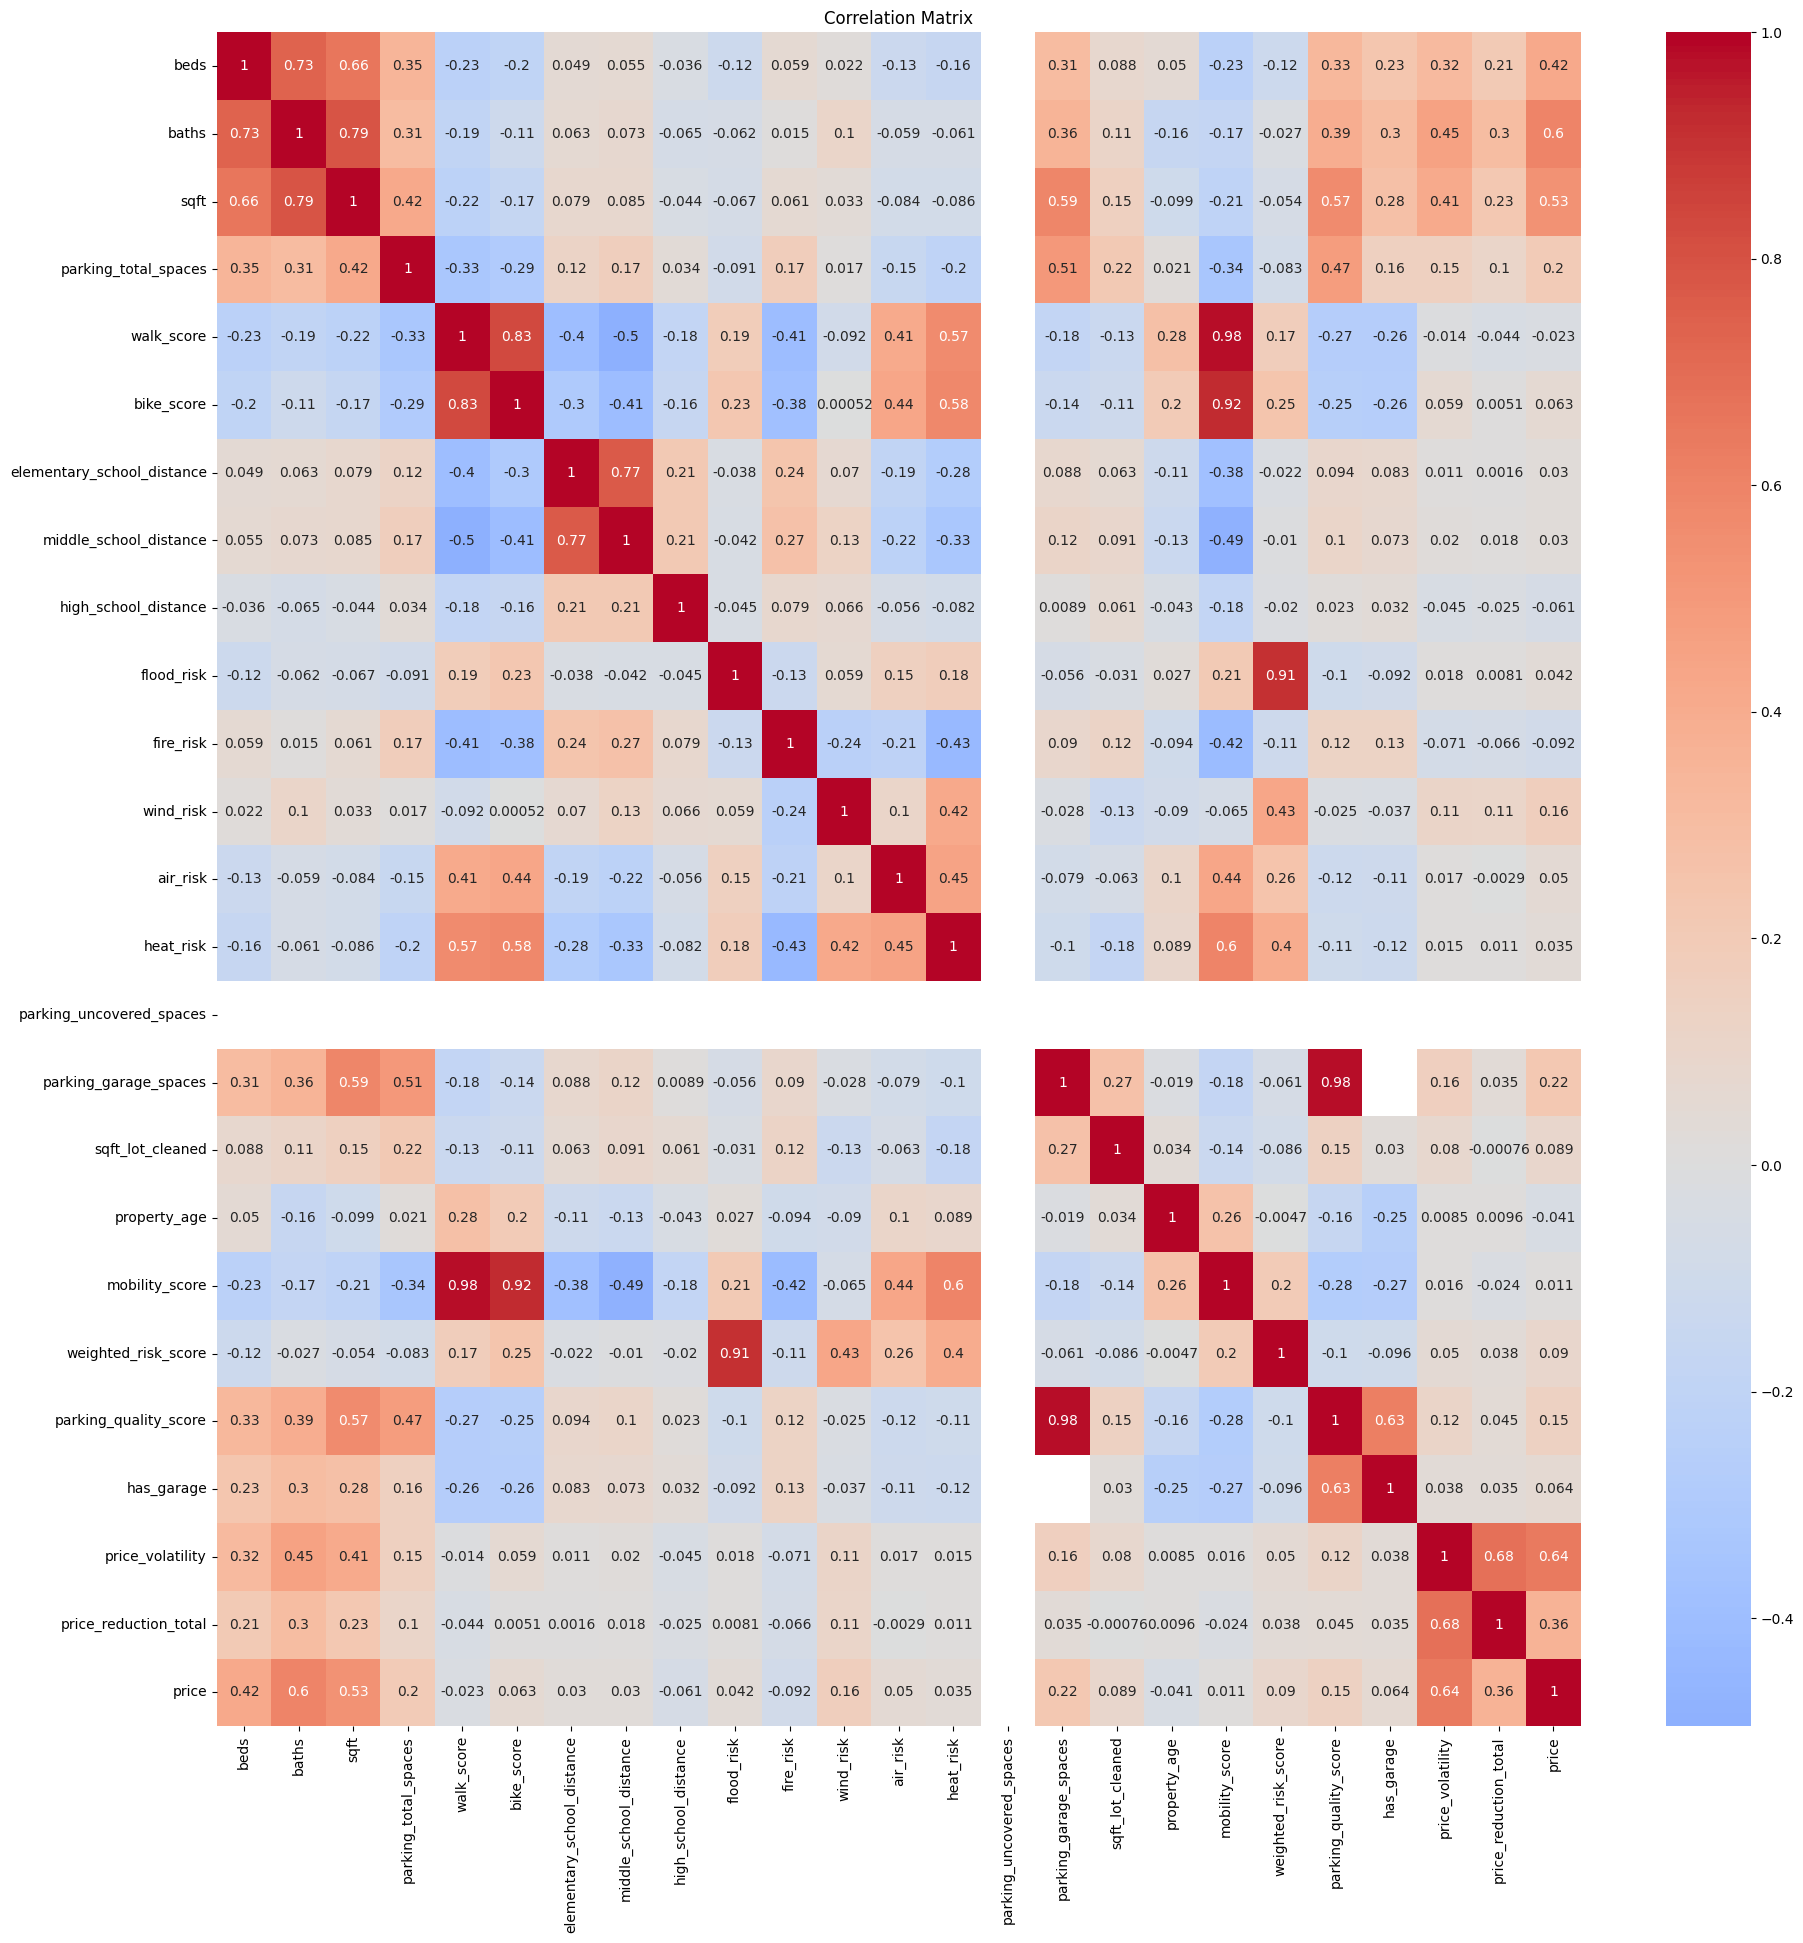

In [121]:
corr_matrix = df[numerical_cols + [target]].corr()
plt.figure(figsize=(22, 22))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [113]:
df.head()

,url,image_url,beds,baths,sqft,sqft_lot,address,property_type,year_built,region,parking_total_spaces,walk_score,bike_score,elementary_school_name,elementary_school_distance,middle_school_name,middle_school_distance,high_school_name,high_school_distance,flood_risk,fire_risk,wind_risk,air_risk,heat_risk,nearby_cities,parking_uncovered_spaces,parking_garage_spaces,price,sqft_lot_caterogy,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,weighted_risk_score,parking_quality_score,has_garage,parking_adequacy,county,zip_price_tier,price_volatility,price_reduction_total
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"5,001 sqft","197 Lowell St, Arlington, MA 02474",single family,1880.0,Arlington,4.0,81.0,61.0,Nearby,NaN,Ottoson,0.4,Arlington,1.4,1.0,1.0,6.0,3.0,5.0,"Arlington, Cambridge, Everett, Framingham, Lowell",NaN,NaN,999000,Ultra Compact,5.0,2474,145.0,73.0,0.900,2.85,0.0,0,Adequate,Middlesex,Mid-tier,190775.778337,481500.0
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"4,818 sqft","225 Mystic St, Arlington, MA 02474",single family,1880.0,Arlington,3.0,69.0,59.0,Bishop,0.1,Ottoson,0.1,Arlington,0.7,1.0,1.0,6.0,3.0,5.0,"Arlington, Cambridge, Everett, Framingham, Lowell",1.0,NaN,799000,Ultra Compact,4.0,2474,145.0,65.0,0.300,2.85,1.0,0,Adequate,Middlesex,Mid-tier,75258.487893,189000.0
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"7,954 sqft","43 Longmeadow Rd, Arlington, MA 02474",single family,1952.0,Arlington,5.0,32.0,35.0,Nearby,5.0,Ottoson,0.2,Additional,5.0,1.0,1.0,6.0,3.0,5.0,"Arlington, Cambridge, Everett, Framingham, Lowell",NaN,NaN,899000,Ultra Compact,7.0,2474,73.0,33.2,3.400,2.85,0.0,0,Abundant,Middlesex,Mid-tier,379500.000000,759000.0
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"6,037 sqft","11 Pine Ct, Arlington, MA 02476",single family,1926.0,Arlington,2.0,84.0,54.0,Brackett,0.7,Ottoson,0.7,Arlington,0.7,1.0,1.0,6.0,3.0,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",NaN,NaN,998000,Ultra Compact,6.0,2476,99.0,72.0,0.700,2.95,0.0,0,Basic,Middlesex,Mid-tier,358034.448994,815000.0
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,NaN,"17 Norcross St FLOOR 3, Arlington, MA 02474",condo,1908.0,Arlington,1.0,77.0,96.0,Thompson,0.1,Ottoson,0.1,Major,5.0,1.0,1.0,6.0,3.0,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",1.0,NaN,668000,Unknown,NaN,2474,117.0,84.6,1.733,2.95,1.0,0,Limited,Middlesex,Mid-tier,16004.999219,-47000.0


In [114]:
df.drop(columns={'sqft_lot','year_built'}, inplace=True)

In [116]:
# Get all columns except price
cols = [col for col in df.columns if col != 'price']
# Add price at the end
cols.append('price')
# Reorder dataframe
df = df[cols]

In [118]:
df.rename(columns={'sqft_lot_caterogy':'sqft_lot_category'}, inplace=True)

In [119]:
df.columns

Index(['url', 'image_url', 'beds', 'baths', 'sqft', 'address', 'property_type',
       'region', 'parking_total_spaces', 'walk_score', 'bike_score',
       'elementary_school_name', 'elementary_school_distance',
       'middle_school_name', 'middle_school_distance', 'high_school_name',
       'high_school_distance', 'flood_risk', 'fire_risk', 'wind_risk',
       'air_risk', 'heat_risk', 'nearby_cities', 'parking_uncovered_spaces',
       'parking_garage_spaces', 'sqft_lot_category', 'sqft_lot_cleaned',
       'zip_code', 'property_age', 'mobility_score',
       'avg_school_distance_miles', 'weighted_risk_score',
       'parking_quality_score', 'has_garage', 'parking_adequacy', 'county',
       'zip_price_tier', 'price_volatility', 'price_reduction_total', 'price'],
      dtype='object')

In [122]:
# Check individual risk correlations
risk_features = ['flood_risk', 'fire_risk', 'wind_risk', 'air_risk', 'heat_risk']
for feature in risk_features:
    corr = df[feature].corr(df['price'])
    print(f"{feature}: {corr:.3f}")

# Keep only the strongest individual risk factors
# Drop weighted_risk_score if it's weaker

flood_risk: 0.042
fire_risk: -0.092
wind_risk: 0.165
air_risk: 0.050
heat_risk: 0.035


In [123]:
# Drop the weak and counterproductive risk features
risk_drops = ['weighted_risk_score', 'fire_risk', 'flood_risk', 'air_risk', 'heat_risk']
df.drop(risk_drops, axis=1, inplace=True)

In [124]:
# Drop redundant features
multicollinear_drops = [
    'high_school_distance',
    'parking_uncovered_spaces',  # parking_total_spaces covers this
    'parking_garage_spaces'
]

df.drop(multicollinear_drops, axis=1, inplace=True)

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7941 entries, 0 to 7940
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         7941 non-null   object 
 1   image_url                   7941 non-null   object 
 2   beds                        7845 non-null   float64
 3   baths                       7854 non-null   float64
 4   sqft                        7838 non-null   float64
 5   address                     7908 non-null   object 
 6   property_type               7941 non-null   object 
 7   region                      7941 non-null   object 
 8   parking_total_spaces        6915 non-null   float64
 9   walk_score                  7608 non-null   float64
 10  bike_score                  7407 non-null   float64
 11  elementary_school_name      6823 non-null   object 
 12  elementary_school_distance  5481 non-null   float64
 13  middle_school_name          6760 

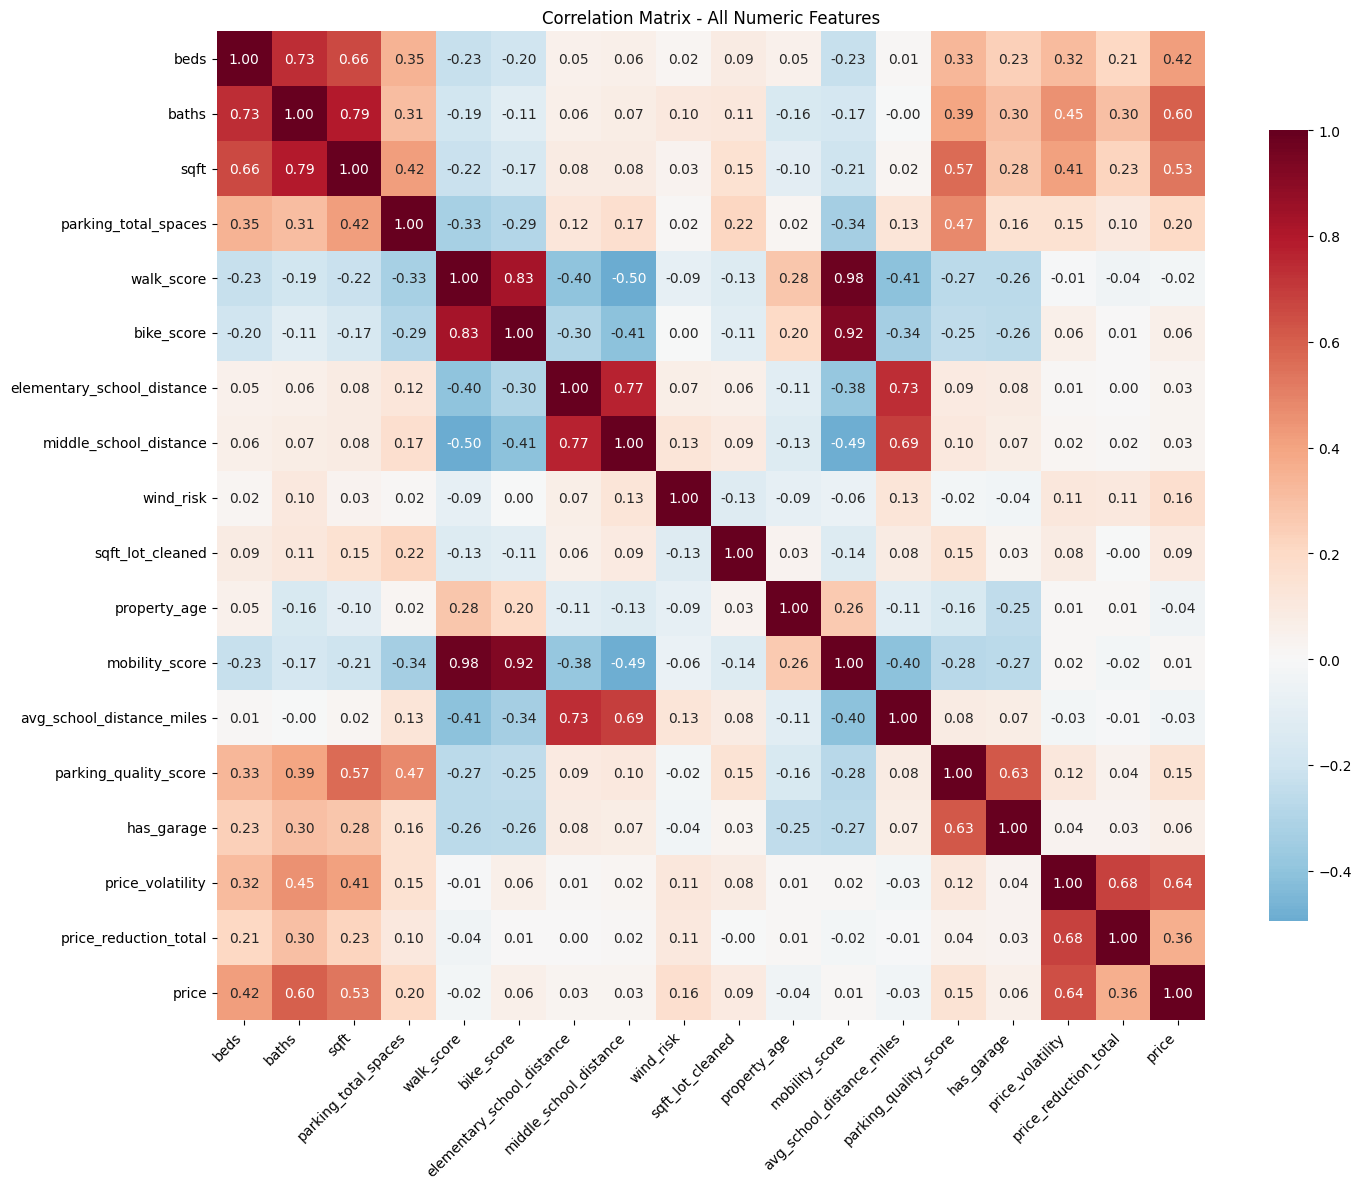

Correlations with Price:
price_volatility: 0.641
baths: 0.599
sqft: 0.533
beds: 0.421
price_reduction_total: 0.361
parking_total_spaces: 0.195
wind_risk: 0.165
parking_quality_score: 0.145
sqft_lot_cleaned: 0.089
has_garage: 0.064
bike_score: 0.063
elementary_school_distance: 0.030
middle_school_distance: 0.030
mobility_score: 0.011
walk_score: -0.023
avg_school_distance_miles: -0.029
property_age: -0.041

High Multicollinearity (>0.7):
beds vs baths: 0.734
baths vs sqft: 0.793
walk_score vs bike_score: 0.834
walk_score vs mobility_score: 0.982
bike_score vs mobility_score: 0.923
elementary_school_distance vs middle_school_distance: 0.771
elementary_school_distance vs avg_school_distance_miles: 0.735

Missing Data Summary:
elementary_school_distance: 2460 (31.0%)
sqft_lot_cleaned: 1967 (24.8%)
parking_total_spaces: 1026 (12.9%)
wind_risk: 772 (9.7%)
mobility_score: 535 (6.7%)
bike_score: 534 (6.7%)
walk_score: 333 (4.2%)
sqft: 103 (1.3%)
beds: 96 (1.2%)
baths: 87 (1.1%)
property_age: 3

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix,
           annot=True,
           cmap='RdBu_r',
           center=0,
           square=True,
           fmt='.2f',
           cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - All Numeric Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Get correlations with price specifically
price_correlations = corr_matrix['price'].sort_values(ascending=False)
print("Correlations with Price:")
print("=" * 30)
for feature, corr in price_correlations.items():
   if feature != 'price':
       print(f"{feature}: {corr:.3f}")

# Check for high multicollinearity (>0.7)
print("\nHigh Multicollinearity (>0.7):")
print("=" * 35)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
   for j in range(i+1, len(corr_matrix.columns)):
       corr_val = corr_matrix.iloc[i, j]
       if abs(corr_val) > 0.7:
           feature1 = corr_matrix.columns[i]
           feature2 = corr_matrix.columns[j]
           high_corr_pairs.append((feature1, feature2, corr_val))
           print(f"{feature1} vs {feature2}: {corr_val:.3f}")

# Missing data summary for numeric features
print("\nMissing Data Summary:")
print("=" * 25)
missing_data = df[numeric_cols].isnull().sum().sort_values(ascending=False)
for feature, missing_count in missing_data.items():
   if missing_count > 0:
       missing_pct = (missing_count / len(df)) * 100
       print(f"{feature}: {missing_count} ({missing_pct:.1f}%)")

In [127]:
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Method 1: Convert categoricals to numeric and check correlation
def categorical_correlation_analysis(df, target='price'):
    results = []

    for col in categorical_cols:
        if col in ['url', 'image_url', 'address']:  # Skip non-predictive columns
            continue

        # Label encode the categorical
        le = LabelEncoder()
        encoded = le.fit_transform(df[col].fillna('Missing'))

        # Calculate correlation with target
        corr = np.corrcoef(encoded, df[target])[0, 1]

        # Count unique values
        unique_count = df[col].nunique()

        results.append({
            'feature': col,
            'correlation': corr,
            'unique_values': unique_count,
            'missing_pct': (df[col].isnull().sum() / len(df)) * 100
        })

    return pd.DataFrame(results).sort_values('correlation', key=abs, ascending=False)

# Method 2: ANOVA F-statistic for categorical vs numeric
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

def anova_categorical_analysis(df, target='price'):
    results = []

    for col in categorical_cols:
        if col in ['url', 'image_url', 'address']:
            continue

        # Create price bins for ANOVA (convert continuous to categorical)
        price_bins = pd.qcut(df[target], q=5, labels=['Low', 'Med-Low', 'Medium', 'Med-High', 'High'])

        # Clean the categorical data
        cat_data = df[col].fillna('Missing')

        # Calculate chi-square test
        contingency_table = pd.crosstab(cat_data, price_bins)
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        results.append({
            'feature': col,
            'chi2_statistic': chi2,
            'p_value': p_value,
            'unique_values': df[col].nunique()
        })

    return pd.DataFrame(results).sort_values('chi2_statistic', ascending=False)

Categorical columns: ['url', 'image_url', 'address', 'property_type', 'region', 'elementary_school_name', 'middle_school_name', 'high_school_name', 'nearby_cities', 'sqft_lot_category', 'zip_code', 'parking_adequacy', 'county', 'zip_price_tier']
Categorical Correlation Analysis:
                   feature  correlation  unique_values  missing_pct
7                 zip_code     0.177740            471     1.876338
6        sqft_lot_category    -0.154491              6     0.000000
5            nearby_cities     0.103274             28     0.000000
1                   region    -0.070121            486     0.000000
10          zip_price_tier    -0.060969              3     0.000000
8         parking_adequacy    -0.042084              4     0.000000
2   elementary_school_name    -0.030679            618    14.078831
0            property_type     0.026211              3     0.000000
9                   county     0.023758             15     0.000000
4         high_school_name     0.005744 

In [128]:
# Drop weak categorical features
weak_categoricals = [
    'elementary_school_name',       # Too many categories (618), weak signal
    'middle_school_name',           # Too many categories (365), weak signal
    'high_school_name',             # Too many categories (1101), weak signal
    'parking_adequacy'              # Weak correlation (-0.042)
]

df.drop(weak_categoricals, axis=1, inplace=True)

In [129]:
df.head()

,url,image_url,beds,baths,sqft,address,property_type,region,parking_total_spaces,walk_score,bike_score,elementary_school_distance,middle_school_distance,wind_risk,nearby_cities,sqft_lot_category,sqft_lot_cleaned,zip_code,property_age,mobility_score,avg_school_distance_miles,parking_quality_score,has_garage,county,zip_price_tier,price_volatility,price_reduction_total,price
0,https://www.zillow.com/homedetails/197-Lowell-...,https://photos.zillowstatic.com/fp/90454dcdc33...,3.0,2.0,1415.0,"197 Lowell St, Arlington, MA 02474",single family,Arlington,4.0,81.0,61.0,NaN,0.4,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",Ultra Compact,5.0,2474,145.0,73.0,0.900,0.0,0,Middlesex,Mid-tier,190775.778337,481500.0,999000
1,https://www.zillow.com/homedetails/225-Mystic-...,https://photos.zillowstatic.com/fp/e92a0b0b33e...,2.0,1.0,1064.0,"225 Mystic St, Arlington, MA 02474",single family,Arlington,3.0,69.0,59.0,0.1,0.1,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",Ultra Compact,4.0,2474,145.0,65.0,0.300,1.0,0,Middlesex,Mid-tier,75258.487893,189000.0,799000
2,https://www.zillow.com/homedetails/43-Longmead...,https://photos.zillowstatic.com/fp/740e93bfcff...,2.0,1.0,1628.0,"43 Longmeadow Rd, Arlington, MA 02474",single family,Arlington,5.0,32.0,35.0,5.0,0.2,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",Ultra Compact,7.0,2474,73.0,33.2,3.400,0.0,0,Middlesex,Mid-tier,379500.000000,759000.0,899000
3,https://www.zillow.com/homedetails/11-Pine-Ct-...,https://photos.zillowstatic.com/fp/bb84e595f96...,3.0,2.0,1824.0,"11 Pine Ct, Arlington, MA 02476",single family,Arlington,2.0,84.0,54.0,0.7,0.7,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",Ultra Compact,6.0,2476,99.0,72.0,0.700,0.0,0,Middlesex,Mid-tier,358034.448994,815000.0,998000
4,https://www.zillow.com/homedetails/17-Norcross...,https://photos.zillowstatic.com/fp/ac474eb496d...,2.0,2.0,1221.0,"17 Norcross St FLOOR 3, Arlington, MA 02474",condo,Arlington,1.0,77.0,96.0,0.1,0.1,6.0,"Arlington, Cambridge, Everett, Framingham, Lowell",Unknown,NaN,2474,117.0,84.6,1.733,1.0,0,Middlesex,Mid-tier,16004.999219,-47000.0,668000


In [130]:
df.shape

(7941, 28)

In [131]:
df.to_csv('housing_data_after_text_feature_eng.csv')